# ETAPA 4. Cálculo correcto del error, heterocedasticidad y selección de modelo

## De dónde venimos y qué pide la retro

La Etapa 3 dejó montados los modelos de pronóstico de `PM2.5` a `t+1`
(SARIMAX, Random Forest, XGBoost, LSTM) para dos estaciones (`NE`, `SO`), con un
primer vistazo al error, a la homocedasticidad y a la autocorrelación de los
residuos. En la junta de retro se pidió **profundizar dos puntos** antes de
seguir sumando estaciones:

1. **Heterocedasticidad y cálculo de los errores.** Los residuos de una serie de
   contaminación no tienen varianza constante (el error crece con la
   concentración) y además están autocorrelacionados. Si el error estándar se
   calcula como si las horas fueran independientes y homocedásticas, sale
   **demasiado angosto** y las comparaciones entre modelos parecen más
   concluyentes de lo que son. Esta etapa recalcula el error con métodos que
   **sí** respetan esa estructura: errores estándar **HAC (Newey–West)**,
   *bootstrap* por bloques, tamaño de muestra efectivo, y descomposición del MSE.

2. **Análisis del error para elegir el mejor modelo.** En vez de mirar un solo
   `MAE` de un único *holdout*, se usa **validación rolling-origin**
   (*walk-forward*, varios folds) para ver la **distribución** del error de cada
   modelo, y la prueba **Diebold–Mariano** (con corrección de muestra pequeña)
   para decidir si un modelo es **significativamente** mejor que otro o si es un
   empate técnico.

Además se **modela la varianza** (GARCH(1,1) sobre los residuos y regresión
cuantílica conformalizada, CQR) para construir **intervalos de predicción
condicionales** y se evalúa su cobertura **justo donde Etapa 3 fallaba**: en las
horas de alta concentración.

### Estaciones de esta etapa

Se pasa de 2 a **5 estaciones** repartidas por la Zona Metropolitana de
Monterrey. `NE` y `SO` se mantienen (comparabilidad con Etapa 3) y se suman
`CE` (centro), `NTE2` (norte) y `SE3` (sureste); las tres con cobertura de
`PM2.5` y meteorología por encima del 90 % en todo 2020–2025.

### Contenido

| Tema | Sección |
|---|---|
| Estaciones y cobertura | 1 |
| Recap de modelos de Etapa 3 y **conjunto de prueba armonizado** | 2 |
| **Validación rolling-origin** (walk-forward, folds) | 3 |
| **Cálculo del error** bajo heterocedasticidad + autocorrelación (HAC, bootstrap, n efectivo, descomposición del MSE) | 4 |
| **Heterocedasticidad por modelo** (BP, White, ARCH, Goldfeld–Quandt) y caracterización de la varianza | 5 |
| **Modelar la varianza → intervalos condicionales** (empírico, por nivel, GARCH, CQR) | 6 |
| **Selección de modelo**: Diebold–Mariano + ranking por folds → tabla de decisión | 7 |
| Resumen multi-estación | 8 |
| Export para la página web | 9 |
| Conclusiones | 10 |

> **Dependencia nueva:** `arch` (modelo GARCH). Instalar con `pip install arch`.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import (
    het_breuschpagan, het_white, het_arch, het_goldfeldquandt, acorr_ljungbox,
)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from scipy import stats

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from arch import arch_model

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

try:                        # 'display' existe en Jupyter; fuera de Jupyter se usa print
    display                 # noqa: F821
except NameError:
    display = print

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

DATA_PATH = Path("output/sima_2020_2025_limpio.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró {DATA_PATH}. Corre primero limpieza_datos.ipynb.")

df = pd.read_parquet(DATA_PATH)
# el parquet trae la columna de estación con un byte no-UTF8 ('estaci?n'); se normaliza
df = df.rename(columns={c: "estacion" for c in df.columns if c.startswith("estaci")})
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

TARGET = "PM2.5"
ESTACIONES = ["NE", "SO", "CE", "NTE2", "SE3"]
METEO = ["TOUT", "RH", "SR", "WSR", "WDR", "RAINF", "PRS"]
CONTEXTO = ["PM10"]
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
VENTANAS = [24, 168]

DIAS_PRUEBA = 60          # holdout final común (igual que Etapa 3)
N_FOLDS = 5              # folds de validación rolling-origin
DIAS_FOLD = 30           # tamaño de cada bloque de prueba en el walk-forward

NOMBRE_LARGO = {
    "NE": "Noreste · San Nicolás", "SO": "Suroeste · Santa Catarina",
    "CE": "Centro · Monterrey", "NTE2": "Norte · Escobedo", "SE3": "Sureste · Juárez",
}
NIVELES_ES = ["bajo", "medio", "alto", "muy_alto"]

print(f"Base: {DATA_PATH}")
print(f"Registros: {len(df):,} | Periodo: {df['fecha_hora'].min()} a {df['fecha_hora'].max()}")
print(f"Estaciones Etapa 4: {ESTACIONES}")

Base: output\sima_2020_2025_limpio.parquet
Registros: 688,184 | Periodo: 2020-01-01 00:00:00 a 2025-06-30 23:00:00
Estaciones Etapa 4: ['NE', 'SO', 'CE', 'NTE2', 'SE3']


## 1. Estaciones y cobertura

Cada estación se modela por separado (nivel base, meteorología y calidad de datos
distintos). Se exige cobertura alta de `PM2.5` y de la meteorología porque los
rezagos y las ventanas móviles necesitan continuidad temporal.

In [2]:
filas_cob = []
for est in ESTACIONES:
    g = df[df["estacion"] == est]
    filas_cob.append({
        "estación": est,
        "nombre": NOMBRE_LARGO[est],
        "registros": len(g),
        "cob_PM2.5_%": g["PM2.5"].notna().mean() * 100,
        "cob_PM10_%": g["PM10"].notna().mean() * 100,
        "cob_meteo_%": g[METEO].notna().mean().mean() * 100,
        "inicio": g["fecha_hora"].min().date(),
        "fin": g["fecha_hora"].max().date(),
    })
cobertura = pd.DataFrame(filas_cob).set_index("estación")
display(cobertura)

# mapa fecha -> temporada (para el análisis de error por temporada de la sección 5)
FECHA_TEMPORADA = (df[["fecha_hora", "temporada"]]
                   .assign(dia=lambda d: d["fecha_hora"].dt.normalize())
                   .drop_duplicates("dia").set_index("dia")["temporada"])

,nombre,registros,cob_PM2.5_%,cob_PM10_%,cob_meteo_%,inicio,fin
estación,,,,,,,
NE,Noreste · San Nicolás,48180,96.102,98.277,92.269,2020-01-01,2025-06-30
SO,Suroeste · Santa Catarina,48041,94.005,98.214,96.043,2020-01-01,2025-06-30
CE,Centro · Monterrey,48190,90.982,98.707,99.163,2020-01-01,2025-06-30
NTE2,Norte · Escobedo,48178,93.489,98.126,99.648,2020-01-01,2025-06-30
SE3,Sureste · Juárez,48178,95.562,97.767,98.936,2020-01-01,2025-06-30


## 2. Recap de modelos de Etapa 3 y conjunto de prueba armonizado

Se reconstruyen las **features** de Etapa 3 (§4) y los mismos modelos:

- **Naive (`t-1`)**: `PM2.5(t+1) = PM2.5(t)`. Piso de comparación.
- **Random Forest** y **XGBoost**: sobre las features horarias.
- **LSTM**: sobre la secuencia de las últimas 24 h.
- **SARIMAX**: sobre la serie **diaria** con exógenas meteorológicas (se compara
  aparte porque vive en otra escala temporal).

### Por qué "armonizado"

La prueba Diebold–Mariano compara el **error hora a hora** de dos modelos sobre
**las mismas horas**. La LSTM de Etapa 3 se evaluaba sobre un subconjunto de
horas distinto (necesita secuencias de 24 h completas), así que aquí se calcula
un **índice horario común** = intersección del índice de las features y del
índice de la LSTM. Naive, RF, XGBoost y LSTM se comparan sobre ese índice; para
SARIMAX (diario) se reporta una tabla separada.

In [3]:
def construir_serie(estacion, variables):
    d = (df.loc[df["estacion"] == estacion, ["fecha_hora"] + variables]
           .set_index("fecha_hora"))
    d = d[~d.index.duplicated(keep="first")].sort_index()
    idx = pd.date_range(d.index.min(), d.index.max(), freq="h")
    return d.reindex(idx)


series_horarias = {est: construir_serie(est, [TARGET] + METEO + CONTEXTO) for est in ESTACIONES}


def construir_features(estacion):
    d = series_horarias[estacion]
    X = pd.DataFrame(index=d.index)
    for L in LAGS:
        X[f"{TARGET}_lag{L}h"] = d[TARGET].shift(L)
    for W in VENTANAS:
        X[f"{TARGET}_media{W}h"] = d[TARGET].shift(1).rolling(W).mean()
        X[f"{TARGET}_std{W}h"] = d[TARGET].shift(1).rolling(W).std()
    h = X.index.hour.to_numpy()
    m = X.index.month.to_numpy()
    X["hora"] = h
    X["dia_semana"] = X.index.dayofweek
    X["mes"] = m
    X["hora_sin"] = np.sin(2 * np.pi * h / 24)
    X["hora_cos"] = np.cos(2 * np.pi * h / 24)
    X["mes_sin"] = np.sin(2 * np.pi * m / 12)
    X["mes_cos"] = np.cos(2 * np.pi * m / 12)
    for v in METEO + CONTEXTO:
        X[f"{v}_lag1h"] = d[v].shift(1)
    y = d[TARGET]
    tabla = pd.concat([X, y.rename("y")], axis=1).dropna()
    return tabla.drop(columns="y"), tabla["y"]


def rf_nuevo():
    return RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=3,
                                 random_state=SEED, n_jobs=-1)


def xgb_nuevo():
    return XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
                        colsample_bytree=0.8, random_state=SEED, n_jobs=-1)


def metricas(y_real, y_pred):
    y_real = np.asarray(y_real, float)
    y_pred = np.asarray(y_pred, float)
    e = y_real - y_pred
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.nanmean(np.abs(e) / np.where(y_real == 0, np.nan, y_real)) * 100
    return {"ME_sesgo": float(np.mean(e)), "MAE": float(np.mean(np.abs(e))),
            "RMSE": float(np.sqrt(np.mean(e ** 2))), "MAPE_%": float(mape)}


# ---- LSTM (idéntica a Etapa 3 §8) --------------------------------------------
VENTANA = 24
VARS_LSTM = [TARGET] + METEO + CONTEXTO


def construir_secuencias(estacion, ventana=VENTANA):
    d = series_horarias[estacion][VARS_LSTM].dropna()
    v = d.to_numpy("float32")
    j = VARS_LSTM.index(TARGET)
    Xs, ys, ts = [], [], []
    for fin in range(ventana, len(v)):
        Xs.append(v[fin - ventana:fin]); ys.append(v[fin, j]); ts.append(d.index[fin])
    return np.array(Xs), np.array(ys, "float32"), pd.DatetimeIndex(ts)


class RedLSTM(nn.Module):
    def __init__(self, n_vars, oculto=48):
        super().__init__()
        self.lstm = nn.LSTM(n_vars, oculto, batch_first=True)
        self.cabeza = nn.Linear(oculto, 1)

    def forward(self, x):
        s, _ = self.lstm(x)
        return self.cabeza(s[:, -1, :]).squeeze(-1)


def entrenar_lstm(estacion, epocas=18, lote=256, lr=1e-3):
    Xs, ys, ts = construir_secuencias(estacion)
    h = DIAS_PRUEBA * 24
    Xtr, Xte, ytr, yte, tte = Xs[:-h], Xs[-h:], ys[:-h], ys[-h:], ts[-h:]
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-6
    Xtr = (Xtr - mu) / sd
    Xte = (Xte - mu) / sd
    j = VARS_LSTM.index(TARGET)
    muy, sdy = mu[j], sd[j]
    cargador = DataLoader(TensorDataset(torch.from_numpy(Xtr),
                                        torch.from_numpy(((ytr - muy) / sdy).astype("float32"))),
                          batch_size=lote, shuffle=True)
    modelo = RedLSTM(len(VARS_LSTM))
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida_fn = nn.MSELoss()
    modelo.train()
    for _ in range(epocas):
        for bx, by in cargador:
            opt.zero_grad()
            loss = perdida_fn(modelo(bx), by)
            loss.backward()
            opt.step()
    modelo.eval()
    with torch.no_grad():
        pred = modelo(torch.from_numpy(Xte)).numpy() * sdy + muy
    return pd.Series(pred, index=tte, name="LSTM")

In [4]:
def ajustar_estacion(est):
    """Entrena los 4 modelos horarios sobre el holdout final común de la estación."""
    X, y = construir_features(est)
    h = DIAS_PRUEBA * 24
    X_tr, X_te, y_tr, y_te = X.iloc[:-h], X.iloc[-h:], y.iloc[:-h], y.iloc[-h:]

    rf = rf_nuevo().fit(X_tr, y_tr)
    xgb = xgb_nuevo().fit(X_tr, y_tr)
    pred = pd.DataFrame(index=X_te.index)
    pred["Naive (t-1)"] = X_te[f"{TARGET}_lag1h"].to_numpy()
    pred["Random Forest"] = rf.predict(X_te)
    pred["XGBoost"] = xgb.predict(X_te)

    lstm_pred = entrenar_lstm(est)
    idx_comun = pred.index.intersection(lstm_pred.index)
    pred = pred.loc[idx_comun]
    pred["LSTM"] = lstm_pred.loc[idx_comun]
    real = y_te.loc[idx_comun]

    return {"X": X, "y": y, "X_tr": X_tr, "X_te": X_te.loc[idx_comun],
            "y_tr": y_tr, "rf": rf, "xgb": xgb,
            "pred": pred, "real": real, "idx": idx_comun}


ajuste = {}
filas_holdout = []
for est in ESTACIONES:
    print(f"Ajustando {est} (RF + XGBoost + LSTM sobre el holdout de {DIAS_PRUEBA} días)...")
    a = ajustar_estacion(est)
    ajuste[est] = a
    for col in ["Naive (t-1)", "Random Forest", "XGBoost", "LSTM"]:
        filas_holdout.append({"estación": est, "modelo": col,
                              **metricas(a["real"], a["pred"][col])})

tabla_holdout = pd.DataFrame(filas_holdout).set_index(["estación", "modelo"])
print("\nDesempeño sobre el holdout final común (t+1, mismo índice horario por estación):")
display(tabla_holdout.round(3))

Ajustando NE (RF + XGBoost + LSTM sobre el holdout de 60 días)...


Ajustando SO (RF + XGBoost + LSTM sobre el holdout de 60 días)...


Ajustando CE (RF + XGBoost + LSTM sobre el holdout de 60 días)...


Ajustando NTE2 (RF + XGBoost + LSTM sobre el holdout de 60 días)...


Ajustando SE3 (RF + XGBoost + LSTM sobre el holdout de 60 días)...



Desempeño sobre el holdout final común (t+1, mismo índice horario por estación):


ME_sesgo   MAE   RMSE  MAPE_%
estación modelo                                      
NE       Naive (t-1)      -0.050 3.493  9.432  14.366
         Random Forest     0.050 3.392  8.570  14.298
         XGBoost           0.340 3.507  8.338  14.260
         LSTM             -0.288 3.993 10.078  23.799
SO       Naive (t-1)       0.032 3.721  8.090  20.375
         Random Forest    -0.542 3.697  8.255  23.123
         XGBoost          -0.843 4.263 10.332  25.756
         LSTM             -0.433 3.671  7.830  23.225
CE       Naive (t-1)      -0.023 2.260  3.474  11.811
         Random Forest     0.003 2.216  3.294  12.261
         XGBoost          -0.035 2.168  3.212  11.900
         LSTM             -0.266 2.250  3.270  13.852
NTE2     Naive (t-1)       0.023 6.784  9.487  61.492
         Random Forest    -0.115 5.844  7.786  62.440
         XGBoost          -0.066 5.682  7.657  59.179
         LSTM             -1.016 5.859  7.748  62.951
SE3      Naive (t-1)      -0.027 5.260  7.529  33.577
         Random Forest     0.837 5.059  6.938  34.666
         XGBoost           1.174 4.938  6.808  33.798
         LSTM              1.827 4.976  6.861  33.467

### SARIMAX diario (referencia, escala distinta)

In [5]:
def interpolar_diaria(s):
    return s.asfreq("D").interpolate(limit_direction="both").ffill().bfill()


ORDEN_SARIMAX = ((1, 1, 1), (1, 0, 1, 7))
series_diarias = {est: series_horarias[est][TARGET].resample("D").mean() for est in ESTACIONES}
meteo_diaria = {est: construir_serie(est, METEO).resample("D").mean() for est in ESTACIONES}

sarimax_holdout = {}
filas_sx = []
for est in ESTACIONES:
    y_d = interpolar_diaria(series_diarias[est])
    X_d = meteo_diaria[est].reindex(y_d.index).interpolate(limit_direction="both").ffill().bfill()
    y_tr, y_te = y_d.iloc[:-DIAS_PRUEBA], y_d.iloc[-DIAS_PRUEBA:]
    X_dtr, X_dte = X_d.iloc[:-DIAS_PRUEBA], X_d.iloc[-DIAS_PRUEBA:]
    mod = SARIMAX(y_tr, exog=X_dtr, order=ORDEN_SARIMAX[0], seasonal_order=ORDEN_SARIMAX[1],
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = mod.get_forecast(steps=DIAS_PRUEBA, exog=X_dte)
    p = fc.predicted_mean
    ic = fc.conf_int(alpha=0.05)
    cob = float(((y_te >= ic.iloc[:, 0]) & (y_te <= ic.iloc[:, 1])).mean())
    sarimax_holdout[est] = {"mae_diario": mean_absolute_error(y_te, p),
                            "rmse_diario": float(np.sqrt(mean_squared_error(y_te, p))),
                            "cobertura_ic95": cob}
    filas_sx.append({"estación": est, **sarimax_holdout[est]})
display(pd.DataFrame(filas_sx).set_index("estación").round(3))

,mae_diario,rmse_diario,cobertura_ic95
estación,,,
NE,5.728,6.767,1.000
SO,8.297,9.871,1.000
CE,10.933,12.763,0.967
NTE2,5.995,6.967,1.000
SE3,5.976,6.836,1.000


## 3. Validación rolling-origin (walk-forward)

Un solo *holdout* de 60 días puede favorecer a un modelo por azar (la temporada
que le tocó). En su lugar se evalúa con **origen móvil**: se parte el final de la
serie en `N_FOLDS = 5` bloques consecutivos de `DIAS_FOLD = 30` días; para cada
bloque se **entrena con todo lo anterior** y se predice el bloque. Así se obtiene
una **distribución** de `MAE` y `RMSE` por modelo (5 valores), no un número
suelto.

- Naive, Random Forest y XGBoost entran en cada fold (se reentrena RF/XGBoost).
- SARIMAX entra en cada fold sobre la serie diaria.
- La **LSTM no** se reentrena por fold (coste de cómputo alto y no cambia la
  conclusión del análisis que pide la retro); se reporta con su holdout de §2.

In [6]:
def rolling_origin(est):
    X, y = ajuste[est]["X"], ajuste[est]["y"]
    y_d = interpolar_diaria(series_diarias[est])
    X_d = meteo_diaria[est].reindex(y_d.index).interpolate(limit_direction="both").ffill().bfill()
    filas = []
    for k in range(N_FOLDS):                       # k=0 es el bloque más reciente
        fin = len(X) - k * DIAS_FOLD * 24
        ini = fin - DIAS_FOLD * 24
        if ini <= DIAS_FOLD * 24:
            break
        X_tr, X_te = X.iloc[:ini], X.iloc[ini:fin]
        y_tr, y_te = y.iloc[:ini], y.iloc[ini:fin]
        t0, t1 = X_te.index.min(), X_te.index.max()

        preds = {"Naive (t-1)": X_te[f"{TARGET}_lag1h"].to_numpy()}
        preds["Random Forest"] = rf_nuevo().fit(X_tr, y_tr).predict(X_te)
        preds["XGBoost"] = xgb_nuevo().fit(X_tr, y_tr).predict(X_te)

        # SARIMAX diario para el mismo tramo de fechas
        mask_tr = y_d.index < t0.normalize()
        mask_te = (y_d.index >= t0.normalize()) & (y_d.index <= t1.normalize())
        try:
            sx = SARIMAX(y_d[mask_tr], exog=X_d[mask_tr], order=ORDEN_SARIMAX[0],
                         seasonal_order=ORDEN_SARIMAX[1], enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False)
            p_sx = sx.get_forecast(steps=int(mask_te.sum()), exog=X_d[mask_te]).predicted_mean
            m_sx = metricas(y_d[mask_te], p_sx)
        except Exception:
            m_sx = {"MAE": np.nan, "RMSE": np.nan}

        fold_id = N_FOLDS - k
        for nombre, p in preds.items():
            m = metricas(y_te, p)
            filas.append({"fold": fold_id, "inicio": t0, "fin": t1, "escala": "horaria",
                          "modelo": nombre, "MAE": m["MAE"], "RMSE": m["RMSE"]})
        filas.append({"fold": fold_id, "inicio": t0, "fin": t1, "escala": "diaria",
                      "modelo": "SARIMAX", "MAE": m_sx["MAE"], "RMSE": m_sx["RMSE"]})
    return pd.DataFrame(filas)


rolling = {}
for est in ESTACIONES:
    print(f"Rolling-origin {est} ...")
    rolling[est] = rolling_origin(est)

Rolling-origin NE ...


Rolling-origin SO ...


Rolling-origin CE ...


Rolling-origin NTE2 ...


Rolling-origin SE3 ...


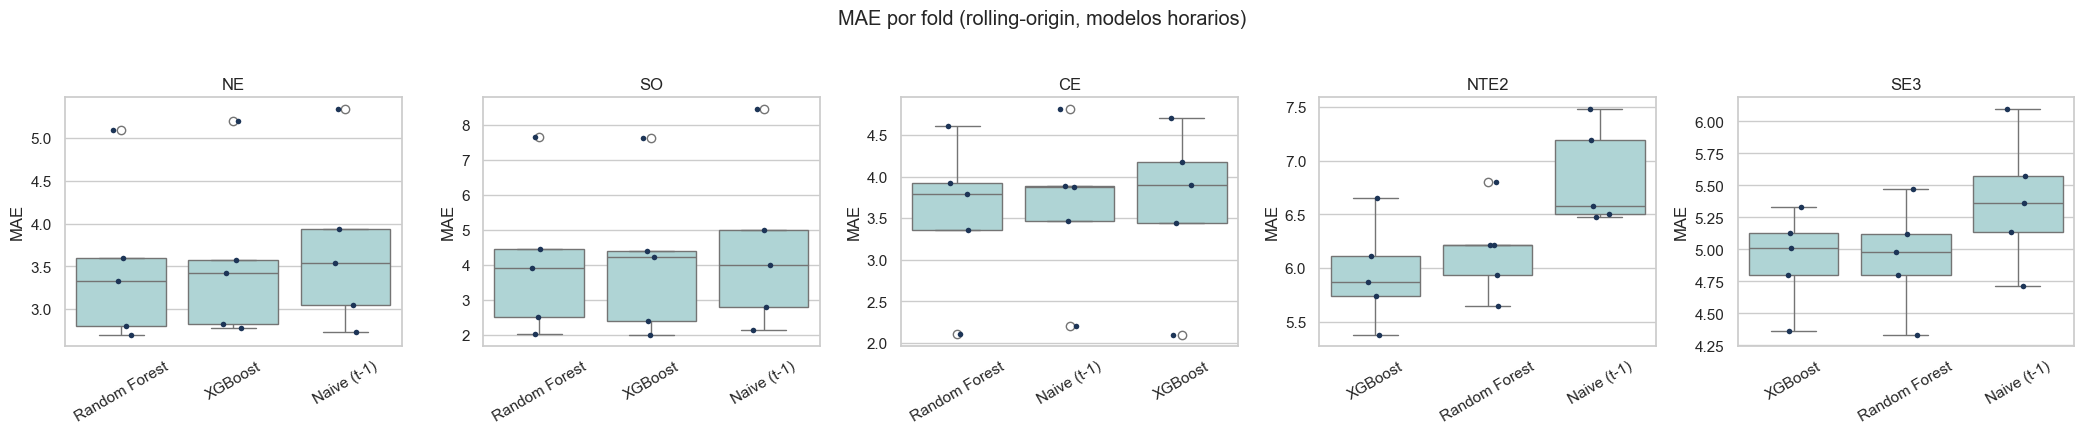


=== NE — resumen rolling-origin (5 folds de 30 días) ===


,MAE_mean,MAE_sd,RMSE_mean,rank_medio
modelo,,,,
Random Forest,3.507,0.961,6.876,1.400
XGBoost,3.564,0.982,6.652,1.800
Naive (t-1),3.722,1.019,7.573,2.800



=== SO — resumen rolling-origin (5 folds de 30 días) ===


,MAE_mean,MAE_sd,RMSE_mean,rank_medio
modelo,,,,
Random Forest,4.127,2.215,6.789,1.800
XGBoost,4.140,2.219,6.900,1.400
Naive (t-1),4.492,2.486,7.551,2.800



=== CE — resumen rolling-origin (5 folds de 30 días) ===


,MAE_mean,MAE_sd,RMSE_mean,rank_medio
modelo,,,,
Random Forest,3.557,0.928,6.077,1.400
Naive (t-1),3.649,0.949,6.150,2.400
XGBoost,3.666,0.988,6.505,2.200



=== NTE2 — resumen rolling-origin (5 folds de 30 días) ===


,MAE_mean,MAE_sd,RMSE_mean,rank_medio
modelo,,,,
XGBoost,5.950,0.474,8.633,1.000
Random Forest,6.164,0.428,8.875,2.000
Naive (t-1),6.848,0.463,9.889,3.000



=== SE3 — resumen rolling-origin (5 folds de 30 días) ===


,MAE_mean,MAE_sd,RMSE_mean,rank_medio
modelo,,,,
XGBoost,4.927,0.370,7.390,1.400
Random Forest,4.942,0.419,7.135,1.600
Naive (t-1),5.379,0.515,7.882,3.000


In [7]:
resumen_folds = {}
fig, axes = plt.subplots(1, len(ESTACIONES), figsize=(4.2 * len(ESTACIONES), 4.2), sharey=False)
for ax, est in zip(np.atleast_1d(axes), ESTACIONES):
    r = rolling[est]
    rh = r[r["escala"] == "horaria"]
    orden = (rh.groupby("modelo")["MAE"].mean().sort_values().index.tolist())
    sns.boxplot(data=rh, x="modelo", y="MAE", order=orden, ax=ax, color="#a8dadc")
    sns.stripplot(data=rh, x="modelo", y="MAE", order=orden, ax=ax, color="#1d3557", size=4)
    ax.set_title(est); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)

    res = (rh.groupby("modelo")
             .agg(MAE_mean=("MAE", "mean"), MAE_sd=("MAE", "std"),
                  RMSE_mean=("RMSE", "mean"))
             .sort_values("MAE_mean"))
    res["rank_medio"] = (rh.pivot_table(index="fold", columns="modelo", values="MAE")
                           .rank(axis=1).mean().reindex(res.index))
    resumen_folds[est] = res
plt.suptitle("MAE por fold (rolling-origin, modelos horarios)", y=1.03)
plt.tight_layout(); plt.show()

for est in ESTACIONES:
    print(f"\n=== {est} — resumen rolling-origin ({N_FOLDS} folds de {DIAS_FOLD} días) ===")
    display(resumen_folds[est].round(3))

## 4. Cálculo del error bajo heterocedasticidad y autocorrelación

Se fija el **modelo campeón por estación** = el de menor `MAE` promedio en el
rolling-origin (§3). Sobre sus residuos del holdout común se calcula el error
"bien":

- **Error estándar del MAE** por tres vías:
  1. **iid**: `sd(|e|)/√n` — supone horas independientes y homocedásticas.
  2. **HAC (Newey–West)**: corrige autocorrelación y heterocedasticidad en la
     media de `|e|` (ancho de banda automático `⌊4(n/100)^{2/9}⌋`).
  3. **Bootstrap por bloques de día**: remuestrea días completos (respeta la
     dependencia intradía).
  El SE **iid casi siempre sale el más chico** → usarlo infla la significancia.
- **Tamaño de muestra efectivo** `n_eff = n·(1−ρ₁)/(1+ρ₁)` con `ρ₁` la
  autocorrelación de rezago 1 de `|e|`: cuántas horas "independientes" equivalen
  las `n` horas reales.
- **Descomposición del MSE**: `MSE = sesgo² + varianza`, y las proporciones de
  **Theil** (sesgo `Uᵐ`, varianza `Uˢ`, covarianza `Uᶜ`; suman 1) más
  `U2 = RMSE_modelo / RMSE_naive`.

In [8]:
def se_hac_media(x, nw_lags=None):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; n = len(x)
    if nw_lags is None:
        nw_lags = max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    m = sm.OLS(x, np.ones(n)).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
    return {"media": float(m.params[0]), "se": float(m.bse[0]), "nw_lags": int(nw_lags),
            "ic95": (float(m.params[0] - 1.96 * m.bse[0]), float(m.params[0] + 1.96 * m.bse[0]))}


def bootstrap_bloques(serie_valor, indice, reps=2000, estad="mean"):
    dfb = pd.DataFrame({"v": np.asarray(serie_valor, float)}, index=pd.DatetimeIndex(indice))
    grupos = [g["v"].to_numpy() for _, g in dfb.groupby(dfb.index.normalize())]
    n = len(grupos)
    out = np.empty(reps)
    for i in range(reps):
        m = np.concatenate([grupos[k] for k in rng.integers(0, n, n)])
        out[i] = m.mean() if estad == "mean" else np.sqrt((m ** 2).mean())
    return np.percentile(out, [2.5, 97.5])


def descomposicion_mse(real, pred, pred_naive):
    real = np.asarray(real, float); pred = np.asarray(pred, float)
    e = real - pred
    mse = float(np.mean(e ** 2))
    sesgo = float(np.mean(e))
    var_e = float(np.var(e))
    r = float(np.corrcoef(real, pred)[0, 1])
    um = (pred.mean() - real.mean()) ** 2 / mse
    us = (pred.std() - real.std()) ** 2 / mse
    uc = 2 * (1 - r) * pred.std() * real.std() / mse
    rmse_naive = float(np.sqrt(np.mean((real - np.asarray(pred_naive, float)) ** 2)))
    return {"MSE": mse, "sesgo2": sesgo ** 2, "var_error": var_e,
            "theil_Um_sesgo": float(um), "theil_Us_varianza": float(us),
            "theil_Uc_covarianza": float(uc),
            "theil_U2_vs_naive": float(np.sqrt(mse) / rmse_naive)}


campeon = {}
for est in ESTACIONES:
    rh = rolling[est]
    rh = rh[rh["escala"] == "horaria"]
    campeon[est] = rh.groupby("modelo")["MAE"].mean().idxmin()
    print(f"{est}: campeón (menor MAE en rolling-origin) = {campeon[est]}")

NE: campeón (menor MAE en rolling-origin) = Random Forest
SO: campeón (menor MAE en rolling-origin) = Random Forest
CE: campeón (menor MAE en rolling-origin) = Random Forest
NTE2: campeón (menor MAE en rolling-origin) = XGBoost
SE3: campeón (menor MAE en rolling-origin) = XGBoost


In [9]:
calc_error = {}
filas_ce = []
for est in ESTACIONES:
    a = ajuste[est]
    nombre = campeon[est]
    real = a["real"].to_numpy()
    pred = a["pred"][nombre].to_numpy()
    pred_naive = a["pred"]["Naive (t-1)"].to_numpy()
    idx = a["idx"]
    e = real - pred
    absre = np.abs(e)

    hac = se_hac_media(absre)
    iid_se = float(np.std(absre, ddof=1) / np.sqrt(len(absre)))
    iid_ic = (hac["media"] - 1.96 * iid_se, hac["media"] + 1.96 * iid_se)
    boot_ic = bootstrap_bloques(absre, idx, reps=2000, estad="mean")
    rho1 = float(acf(absre, nlags=1, fft=False)[1])
    n_eff = len(absre) * (1 - rho1) / (1 + rho1)
    desc = descomposicion_mse(real, pred, pred_naive)

    calc_error[est] = {"campeon": nombre, "n": len(absre), "n_eff": float(n_eff),
                       "rho1_abs_e": rho1, "mae": hac["media"],
                       "se_iid": iid_se, "se_hac": hac["se"], "hac_lags": hac["nw_lags"],
                       "ic95_iid": iid_ic, "ic95_hac": hac["ic95"],
                       "ic95_boot": (float(boot_ic[0]), float(boot_ic[1])), **desc}
    filas_ce.append({
        "estación": est, "campeón": nombre, "MAE": hac["media"],
        "SE_iid": iid_se, "SE_HAC": hac["se"], "razón_HAC/iid": hac["se"] / iid_se,
        "n": len(absre), "n_eff": n_eff, "acf1_abs_e": rho1,
        "IC95_iid": f"[{iid_ic[0]:.2f}, {iid_ic[1]:.2f}]",
        "IC95_HAC": f"[{hac['ic95'][0]:.2f}, {hac['ic95'][1]:.2f}]",
        "IC95_boot": f"[{boot_ic[0]:.2f}, {boot_ic[1]:.2f}]",
    })

tabla_calc_error = pd.DataFrame(filas_ce).set_index("estación")
print("Error estándar del MAE — iid vs HAC vs bootstrap por bloques:")
display(tabla_calc_error.round(3))
print("\nLa columna razón_HAC/iid > 1 indica cuánto subestima el SE iid la incertidumbre "
      "real del MAE (autocorrelación + heterocedasticidad). n_eff << n confirma que las "
      "horas no son observaciones independientes.")

Error estándar del MAE — iid vs HAC vs bootstrap por bloques:


,campeón,MAE,SE_iid,SE_HAC,razón_HAC/iid,n,n_eff,acf1_abs_e,IC95_iid,IC95_HAC,IC95_boot
estación,,,,,,,,,,,
NE,Random Forest,3.392,0.246,0.380,1.546,1024,386.556,0.452,"[2.91, 3.87]","[2.65, 4.14]","[2.88, 4.12]"
SO,Random Forest,3.697,0.305,0.485,1.588,585,153.820,0.584,"[3.10, 4.30]","[2.75, 4.65]","[2.71, 4.91]"
CE,Random Forest,2.216,0.079,0.112,1.415,942,537.838,0.273,"[2.06, 2.37]","[2.00, 2.44]","[1.95, 2.49]"
NTE2,XGBoost,5.682,0.149,0.203,1.367,1190,726.723,0.242,"[5.39, 5.97]","[5.28, 6.08]","[5.21, 6.22]"
SE3,XGBoost,4.938,0.168,0.228,1.357,780,480.254,0.238,"[4.61, 5.27]","[4.49, 5.38]","[4.37, 5.48]"



La columna razón_HAC/iid > 1 indica cuánto subestima el SE iid la incertidumbre real del MAE (autocorrelación + heterocedasticidad). n_eff << n confirma que las horas no son observaciones independientes.


In [10]:
filas_desc = []
for est in ESTACIONES:
    c = calc_error[est]
    filas_desc.append({
        "estación": est, "campeón": c["campeon"], "MSE": c["MSE"],
        "sesgo²": c["sesgo2"], "varianza_error": c["var_error"],
        "Theil_Um_sesgo": c["theil_Um_sesgo"], "Theil_Us_var": c["theil_Us_varianza"],
        "Theil_Uc_cov": c["theil_Uc_covarianza"], "Theil_U2_vs_naive": c["theil_U2_vs_naive"],
    })
tabla_desc = pd.DataFrame(filas_desc).set_index("estación")
print("Descomposición del MSE (Theil: Um+Us+Uc = 1; U2 < 1 => mejor que el ingenuo):")
display(tabla_desc.round(3))

Descomposición del MSE (Theil: Um+Us+Uc = 1; U2 < 1 => mejor que el ingenuo):


,campeón,MSE,sesgo²,varianza_error,Theil_Um_sesgo,Theil_Us_var,Theil_Uc_cov,Theil_U2_vs_naive
estación,,,,,,,,
NE,Random Forest,73.448,0.002,73.446,0.000,0.004,0.996,0.909
SO,Random Forest,68.139,0.293,67.846,0.004,0.056,0.940,1.020
CE,Random Forest,10.853,0.000,10.853,0.000,0.048,0.952,0.948
NTE2,XGBoost,58.624,0.004,58.620,0.000,0.169,0.831,0.807
SE3,XGBoost,46.345,1.378,44.967,0.030,0.118,0.853,0.904


## 5. Heterocedasticidad por modelo y caracterización de la varianza

Etapa 3 solo revisaba el campeón. Aquí se corren cuatro pruebas sobre los
residuos del holdout común para **los cuatro modelos horarios**, por estación:

- **Breusch–Pagan** y **White**: ¿la varianza del residuo depende del valor
  ajustado (y su cuadrado)?
- **ARCH(24)** (Engle): ¿hay heterocedasticidad *condicional* (varianza que se
  agrupa en el tiempo)?
- **Goldfeld–Quandt**: ordenando por pronóstico, ¿la varianza del tercio alto es
  mayor que la del tercio bajo?

Después, para el campeón: `|e|` y `e²` contra el **nivel pronosticado** (deciles),
contra la **hora** y contra la **temporada**; y una regresión
`log(e² + 1) ~ ŷ + ŷ²` para cuantificar cuánto crece la varianza por µg/m³.

In [11]:
def pruebas_heterocedasticidad(e, pred):
    e = np.asarray(e, float); pred = np.asarray(pred, float)
    exog = sm.add_constant(np.column_stack([pred, pred ** 2]))
    bp = het_breuschpagan(e, exog)[1]
    wh = het_white(e, exog)[1]
    ar = het_arch(e, nlags=24)[1]
    try:
        gq = het_goldfeldquandt(e, sm.add_constant(pred.reshape(-1, 1)), idx=1,
                                alternative="increasing")[1]
    except Exception:
        gq = np.nan
    return {"Breusch_Pagan_p": float(bp), "White_p": float(wh),
            "ARCH24_p": float(ar), "Goldfeld_Quandt_p": float(gq)}


filas_het = []
for est in ESTACIONES:
    a = ajuste[est]
    real = a["real"].to_numpy()
    for col in ["Naive (t-1)", "Random Forest", "XGBoost", "LSTM"]:
        p = a["pred"][col].to_numpy()
        pr = pruebas_heterocedasticidad(real - p, p)
        pr["homocedástico_5%"] = "sí" if min(v for v in pr.values() if np.isfinite(v)) > 0.05 else "NO"
        filas_het.append({"estación": est, "modelo": col, **pr})

tabla_het = pd.DataFrame(filas_het).set_index(["estación", "modelo"])
print("Pruebas de heterocedasticidad por modelo (p-valores; p<0.05 rechaza varianza constante):")
display(tabla_het.round(4))
print("\nEl rechazo es prácticamente universal: la heterocedasticidad no es un defecto "
      "de un modelo concreto sino de la serie de PM2.5.")

Pruebas de heterocedasticidad por modelo (p-valores; p<0.05 rechaza varianza constante):


Breusch_Pagan_p  White_p  ARCH24_p  Goldfeld_Quandt_p  \
estación modelo                                                                 
NE       Naive (t-1)              0.000    0.000     0.000              0.000   
         Random Forest            0.000    0.000     0.000              0.000   
         XGBoost                  0.000    0.000     0.000              0.000   
         LSTM                     0.000    0.000     0.991              0.000   
SO       Naive (t-1)              0.000    0.000     0.000              0.000   
         Random Forest            0.000    0.000     0.000              0.000   
         XGBoost                  0.000    0.000     0.000              0.000   
         LSTM                     0.000    0.000     0.000              0.000   
CE       Naive (t-1)              0.000    0.000     0.000              0.000   
         Random Forest            0.000    0.000     0.000              0.000   
         XGBoost                  0.000    0.000     0.020              0.000   
         LSTM                     0.000    0.001     0.000              0.000   
NTE2     Naive (t-1)              0.000    0.000     0.000              0.000   
         Random Forest            0.000    0.000     0.000              0.000   
         XGBoost                  0.000    0.000     0.000              0.000   
         LSTM                     0.000    0.000     0.000              0.000   
SE3      Naive (t-1)              0.000    0.000     0.000              0.000   
         Random Forest            0.000    0.000     0.000              0.000   
         XGBoost                  0.000    0.000     0.000              0.000   
         LSTM                     0.000    0.000     0.000              0.000   

                       homocedástico_5%  
estación modelo                          
NE       Naive (t-1)                 NO  
         Random Forest               NO  
         XGBoost                     NO  
         LSTM                        NO  
SO       Naive (t-1)                 NO  
         Random Forest               NO  
         XGBoost                     NO  
         LSTM                        NO  
CE       Naive (t-1)                 NO  
         Random Forest               NO  
         XGBoost                     NO  
         LSTM                        NO  
NTE2     Naive (t-1)                 NO  
         Random Forest               NO  
         XGBoost                     NO  
         LSTM                        NO  
SE3      Naive (t-1)                 NO  
         Random Forest               NO  
         XGBoost                     NO  
         LSTM                        NO


El rechazo es prácticamente universal: la heterocedasticidad no es un defecto de un modelo concreto sino de la serie de PM2.5.


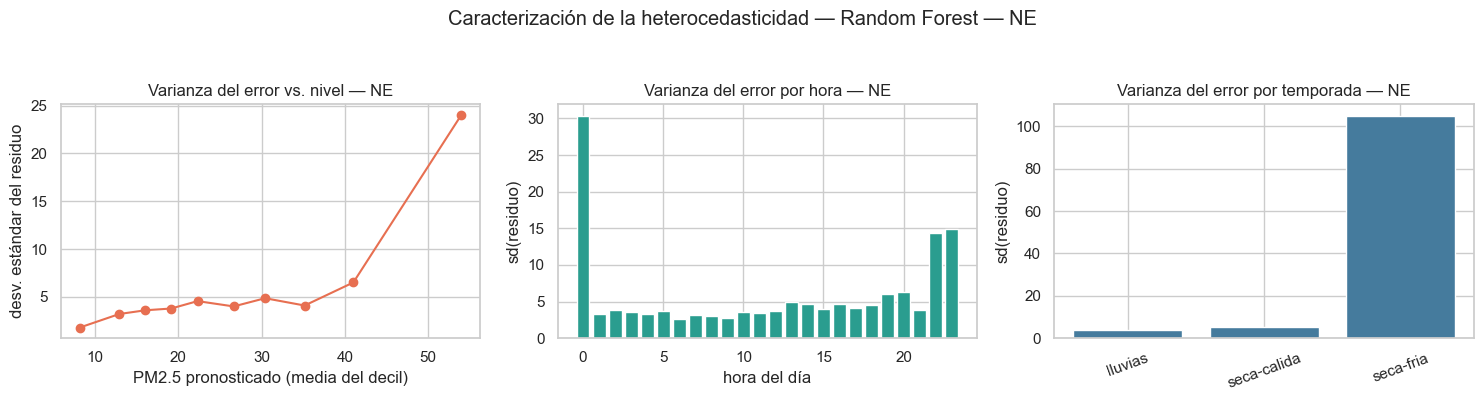

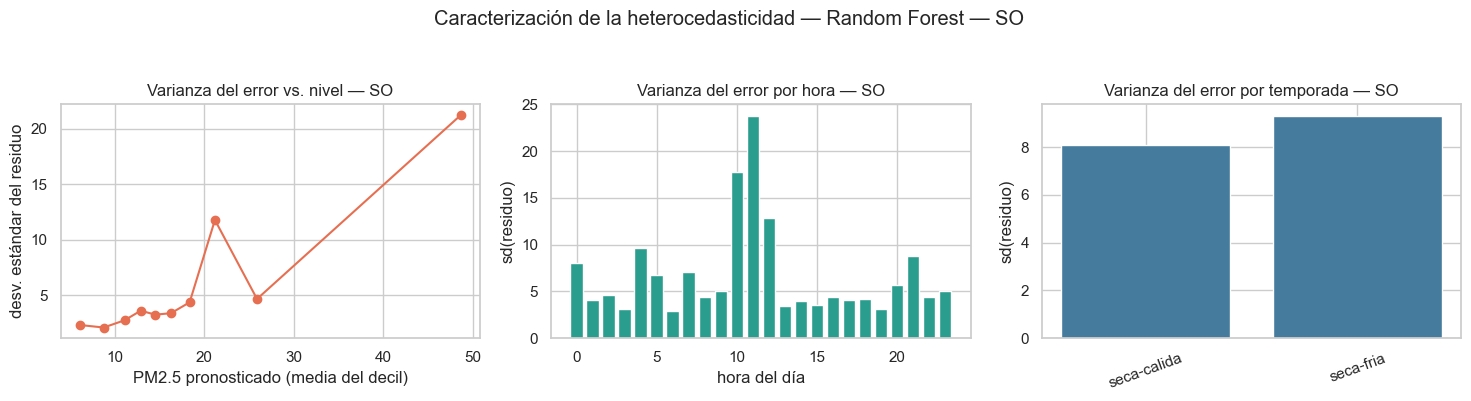

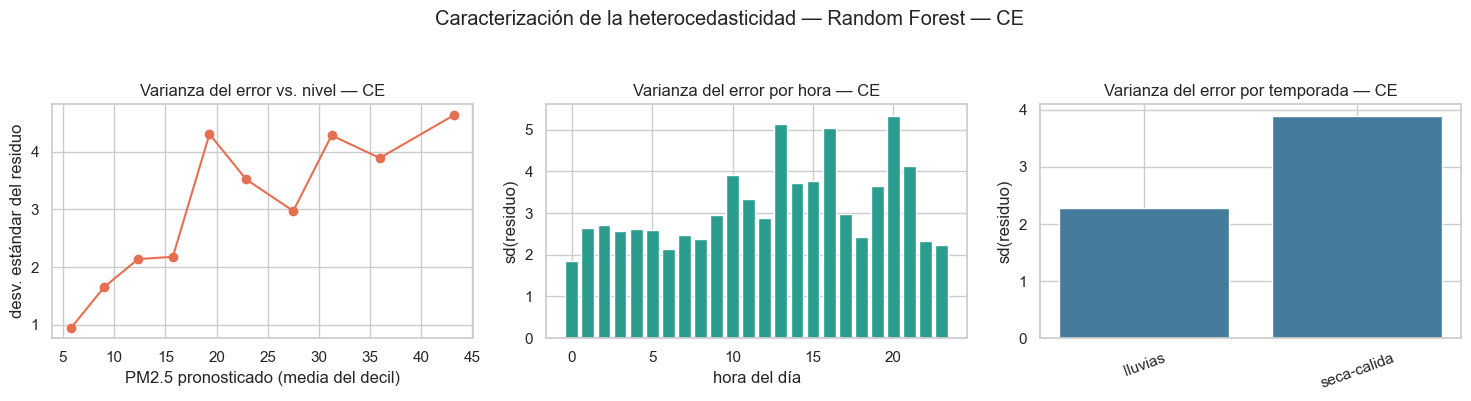

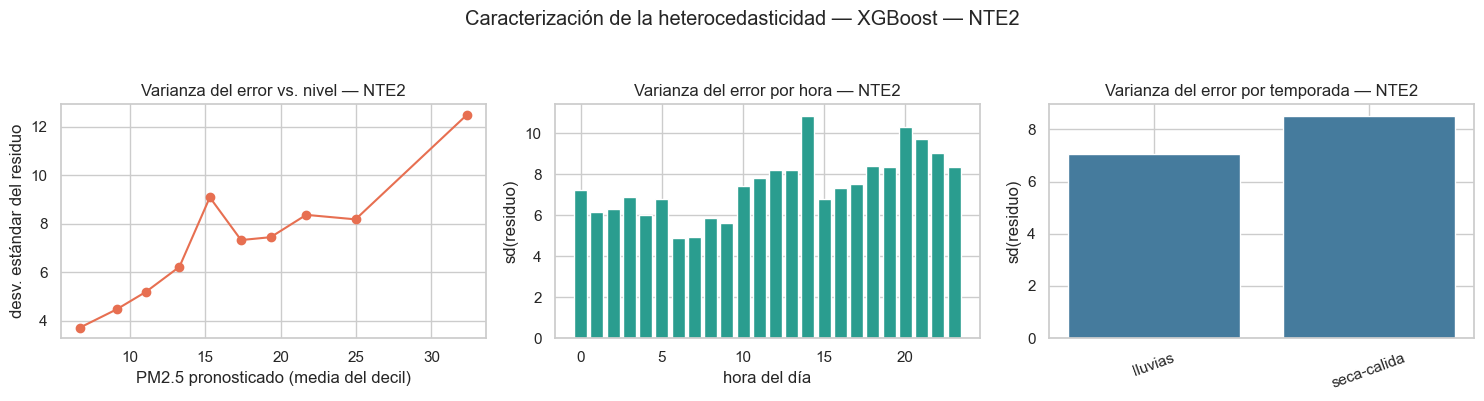

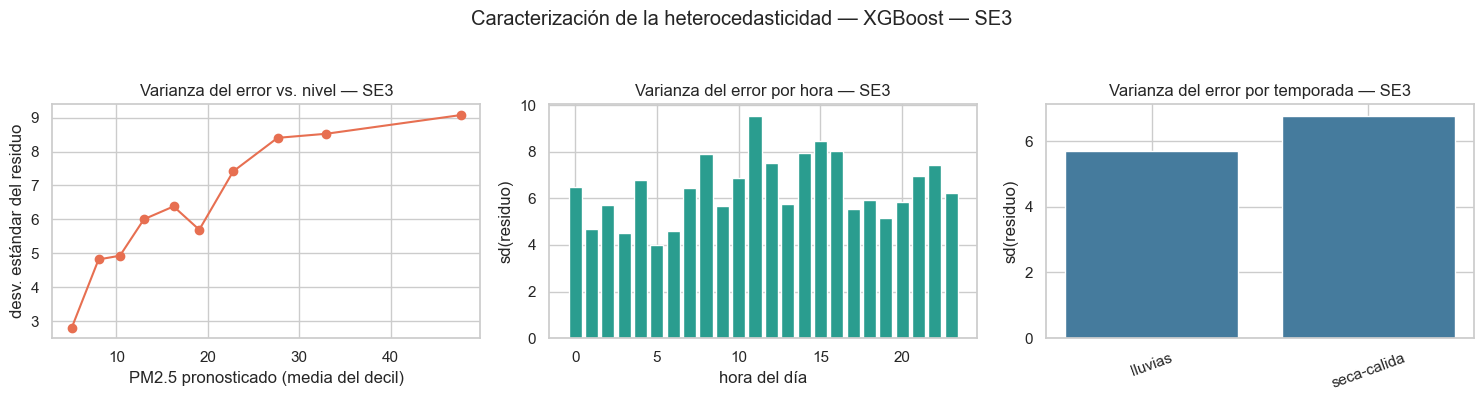

Cuánto crece la varianza del error con el nivel pronosticado:


,campeón,pendiente_log_e2_por_pred,R²_regresión,factor_degradación_q4/q1
estación,,,,
NE,Random Forest,0.031,0.135,5.498
SO,Random Forest,0.090,0.257,6.011
CE,Random Forest,0.067,0.143,2.796
NTE2,XGBoost,0.118,0.088,2.311
SE3,XGBoost,0.084,0.108,2.152


In [12]:
carac_var = {}
for est in ESTACIONES:
    a = ajuste[est]
    nombre = campeon[est]
    real = a["real"].to_numpy()
    pred = a["pred"][nombre].to_numpy()
    e = real - pred
    idx = a["idx"]
    d = pd.DataFrame({"pred": pred, "e": e, "abs_e": np.abs(e), "e2": e ** 2}, index=idx)
    d["hora"] = d.index.hour
    d["temporada"] = FECHA_TEMPORADA.reindex(d.index.normalize()).to_numpy()
    d["decil_pred"] = pd.qcut(d["pred"], 10, labels=False, duplicates="drop")

    por_decil = d.groupby("decil_pred").agg(pred_medio=("pred", "mean"),
                                            std_e=("e", "std"), mae=("abs_e", "mean"),
                                            n=("e", "size"))
    por_hora = d.groupby("hora")["e"].std()
    por_temp = d.groupby("temporada")["e"].agg(std_e="std", mae=lambda s: s.abs().mean())

    # regresión log(e^2 + 1) ~ pred + pred^2
    Xr = sm.add_constant(np.column_stack([pred, pred ** 2]))
    reg = sm.OLS(np.log(e ** 2 + 1.0), Xr).fit()
    q = d.groupby(pd.qcut(d["pred"], 4, duplicates="drop"), observed=True)["e"].std()
    factor_deg = float(q.iloc[-1] / q.iloc[0]) if len(q) >= 2 else np.nan

    carac_var[est] = {"por_decil": por_decil, "reg_pendiente_pred": float(reg.params[1]),
                      "reg_r2": float(reg.rsquared), "factor_degradacion": factor_deg,
                      "por_temp": por_temp}

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    axes[0].plot(por_decil["pred_medio"], por_decil["std_e"], "o-", color="#e76f51")
    axes[0].set_xlabel("PM2.5 pronosticado (media del decil)")
    axes[0].set_ylabel("desv. estándar del residuo")
    axes[0].set_title(f"Varianza del error vs. nivel — {est}")
    axes[1].bar(por_hora.index, por_hora.values, color="#2a9d8f")
    axes[1].set_xlabel("hora del día"); axes[1].set_ylabel("sd(residuo)")
    axes[1].set_title(f"Varianza del error por hora — {est}")
    axes[2].bar(por_temp.index.astype(str), por_temp["std_e"].values, color="#457b9d")
    axes[2].set_ylabel("sd(residuo)"); axes[2].set_title(f"Varianza del error por temporada — {est}")
    axes[2].tick_params(axis="x", rotation=20)
    plt.suptitle(f"Caracterización de la heterocedasticidad — {campeon[est]} — {est}", y=1.05)
    plt.tight_layout(); plt.show()

filas_cv = [{"estación": est, "campeón": campeon[est],
             "pendiente_log_e2_por_pred": carac_var[est]["reg_pendiente_pred"],
             "R²_regresión": carac_var[est]["reg_r2"],
             "factor_degradación_q4/q1": carac_var[est]["factor_degradacion"]}
            for est in ESTACIONES]
print("Cuánto crece la varianza del error con el nivel pronosticado:")
display(pd.DataFrame(filas_cv).set_index("estación").round(4))

## 6. Modelar la varianza → intervalos de predicción condicionales

Se comparan **cuatro** formas de poner una banda del 95 % (y 80 %) alrededor del
pronóstico del campeón. Los residuos de calibración salen de un tramo de
**validación** de 30 días **anterior** a la prueba (no usado hasta aquí).

| Método | Idea | Qué corrige |
|---|---|---|
| **Empírico global** | cuantiles 2.5/97.5 de los residuos de validación → banda constante | nada (línea base de Etapa 3) |
| **Por nivel** | cuantiles de residuos dentro de *bins* del pronóstico | heterocedasticidad respecto al nivel |
| **GARCH(1,1)** | `σ_t² = ω + α·e_{t-1}² + β·σ_{t-1}²` recursivo con los residuos reales pasados → banda `±1.96·σ_t` | heterocedasticidad *condicional* (agrupamiento temporal) |
| **CQR** | regresión cuantílica (GradientBoosting) 2.5/97.5 + conformalización sobre validación | heterocedasticidad respecto a *todas* las features |

Cada método se evalúa por **cobertura global** y **cobertura en el cuartil alto**
de concentración (donde Etapa 3 quedaba corto), más el **ancho medio**.

In [13]:
# nivel de confianza -> (z para GARCH, cuantiles inferior/superior en %)
NIVELES_IC = {"95": (1.96, 2.5, 97.5), "80": (1.2816, 10.0, 90.0)}


def garch_ajuste(resid_ajuste):
    r = arch_model(np.asarray(resid_ajuste, float), mean="Zero", vol="GARCH",
                   p=1, q=1, dist="normal", rescale=False).fit(disp="off")
    return {"omega": float(r.params["omega"]), "alpha": float(r.params["alpha[1]"]),
            "beta": float(r.params["beta[1]"]),
            "persistencia": float(r.params["alpha[1]"] + r.params["beta[1]"]),
            "sig2_0": float(r.conditional_volatility[-1] ** 2)}


def garch_sigma(par, resid_ajuste, resid_prueba):
    """sigma_t de un paso, recursivo con los residuos reales pasados (info hasta t-1)."""
    w, al, be = par["omega"], par["alpha"], par["beta"]
    sig2 = par["sig2_0"]
    e2_prev = float(resid_ajuste[-1] ** 2)
    out = np.empty(len(resid_prueba))
    for i, er in enumerate(resid_prueba):
        sig2 = w + al * e2_prev + be * sig2
        out[i] = np.sqrt(sig2)
        e2_prev = float(er) ** 2
    return out


def cqr_modelos(X_tr, y_tr, alpha):
    kw = dict(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=SEED)
    lo = GradientBoostingRegressor(loss="quantile", alpha=alpha / 2, **kw).fit(X_tr, y_tr)
    hi = GradientBoostingRegressor(loss="quantile", alpha=1 - alpha / 2, **kw).fit(X_tr, y_tr)
    return lo, hi


def cqr_banda(lo_m, hi_m, X_cal, y_cal, X_te, alpha):
    E = np.maximum(lo_m.predict(X_cal) - y_cal.to_numpy(), y_cal.to_numpy() - hi_m.predict(X_cal))
    Q = float(np.quantile(E, min(1.0, (1 - alpha) * (1 + 1 / len(E)))))
    return lo_m.predict(X_te) - Q, hi_m.predict(X_te) + Q


def cobertura(real, lo, hi):
    real = np.asarray(real, float)
    return float(((real >= lo) & (real <= hi)).mean()), float(np.mean(hi - lo))


intervalos = {}
filas_int = []
for est in ESTACIONES:
    a = ajuste[est]
    nombre = campeon[est]
    X, y = a["X"], a["y"]
    h_te = DIAS_PRUEBA * 24
    h_val = 30 * 24
    X_val, y_val = X.iloc[-(h_te + h_val):-h_te], y.iloc[-(h_te + h_val):-h_te]
    X_tr_full, y_tr_full = X.iloc[:-(h_te + h_val)], y.iloc[:-(h_te + h_val)]

    real = a["real"].to_numpy()
    pred = a["pred"][nombre].to_numpy()
    idx = a["idx"]

    # pronóstico en validación del modelo campeón (RF sustituye a la LSTM para bandas por features)
    modelo_arbol = a["xgb"] if nombre == "XGBoost" else a["rf"]
    pred_val = (X_val[f"{TARGET}_lag1h"].to_numpy() if nombre == "Naive (t-1)"
                else modelo_arbol.predict(X_val))
    resid_val = y_val.to_numpy() - pred_val
    resid_te = real - pred

    q4 = pd.qcut(pd.Series(real, index=idx), 4, labels=False, duplicates="drop")
    mask_alto = (q4 == q4.max()).to_numpy()

    garch_par = garch_ajuste(resid_val)
    sig_te = garch_sigma(garch_par, resid_val, resid_te)
    cqr_m = {niv: cqr_modelos(X_tr_full, y_tr_full, al)
             for niv, al in [("95", 0.05), ("80", 0.20)]}

    metodos = {}                                   # metodo -> {cob95, ancho95, cob95_q4, ..., cob80, ...}
    banda_por_metodo_95 = {}
    for m in ["empírico_global", "por_nivel", "GARCH(1,1)", "CQR"]:
        reg = {}
        for niv, (z, plo, phi) in NIVELES_IC.items():
            if m == "empírico_global":
                ql, qh = np.percentile(resid_val, [plo, phi])
                lo, hi = pred + ql, pred + qh
            elif m == "por_nivel":
                bins = np.quantile(pred_val, np.linspace(0, 1, 6))
                bins[0], bins[-1] = -np.inf, np.inf
                b_val = np.digitize(pred_val, bins[1:-1]); b_te = np.digitize(pred, bins[1:-1])
                lo = np.empty_like(pred); hi = np.empty_like(pred)
                for b in np.unique(b_te):
                    r = resid_val[b_val == b]
                    r = r if len(r) >= 30 else resid_val
                    ql, qh = np.percentile(r, [plo, phi])
                    lo[b_te == b] = pred[b_te == b] + ql
                    hi[b_te == b] = pred[b_te == b] + qh
            elif m == "GARCH(1,1)":
                lo, hi = pred - z * sig_te, pred + z * sig_te
            else:                                  # CQR
                lo, hi = cqr_banda(*cqr_m[niv], X_val, y_val, a["X_te"], float(niv == "95") * 0.05 + float(niv == "80") * 0.20)
            cg, wg = cobertura(real, lo, hi)
            ca, _ = cobertura(real[mask_alto], lo[mask_alto], hi[mask_alto])
            reg[f"cob{niv}"] = cg; reg[f"ancho{niv}"] = wg; reg[f"cob{niv}_q4"] = ca
            if niv == "95":
                banda_por_metodo_95[m] = (lo, hi)
        metodos[m] = reg
        filas_int.append({"estación": est, "método": m,
                          "cobertura95": reg["cob95"], "cobertura95_q4alto": reg["cob95_q4"],
                          "ancho95": reg["ancho95"], "cobertura80": reg["cob80"],
                          "cobertura80_q4alto": reg["cob80_q4"], "ancho80": reg["ancho80"]})

    # elegido: el más angosto que NO subcubre en el cuartil alto (cob95_q4 >= 0.93) ni global;
    # si ninguno califica, el de mayor cobertura en el cuartil alto.
    ok = [m for m in metodos if metodos[m]["cob95_q4"] >= 0.93 and metodos[m]["cob95"] >= 0.93]
    elegido = (min(ok, key=lambda m: metodos[m]["ancho95"]) if ok
               else max(metodos, key=lambda m: metodos[m]["cob95_q4"]))
    intervalos[est] = {"metodos": metodos, "elegido": elegido, "garch": garch_par,
                       "banda_elegida": banda_por_metodo_95[elegido], "mask_alto": mask_alto}

tabla_int = pd.DataFrame(filas_int).set_index(["estación", "método"])
print("Cobertura y ancho de los intervalos por método (objetivo de cobertura: 0.95 y 0.80):")
display(tabla_int.round(3))
for est in ESTACIONES:
    g = intervalos[est]["garch"]
    nota = " [IGARCH: varianza no estacionaria]" if g["persistencia"] >= 0.999 else ""
    print(f"{est}: método elegido = {intervalos[est]['elegido']}  "
          f"(GARCH alpha+beta = {g['persistencia']:.3f}){nota}")

Cobertura y ancho de los intervalos por método (objetivo de cobertura: 0.95 y 0.80):


cobertura95  cobertura95_q4alto  ancho95  \
estación método                                                      
NE       empírico_global        0.827               0.757   10.099   
         por_nivel              0.858               0.894   11.809   
         GARCH(1,1)             0.939               0.914   19.289   
         CQR                    0.943               0.949   21.126   
SO       empírico_global        0.901               0.781   17.085   
         por_nivel              0.791               0.747   10.155   
         GARCH(1,1)             0.921               0.829   19.732   
         CQR                    0.971               0.966   21.650   
CE       empírico_global        0.962               0.907   14.295   
         por_nivel              0.920               0.953   11.535   
         GARCH(1,1)             0.966               0.936   13.716   
         CQR                    0.985               0.996   17.253   
NTE2     empírico_global        0.874               0.752   21.410   
         por_nivel              0.839               0.798   19.918   
         GARCH(1,1)             0.912               0.809   23.953   
         CQR                    0.950               0.918   29.538   
SE3      empírico_global        0.871               0.757   19.259   
         por_nivel              0.838               0.801   17.380   
         GARCH(1,1)             0.885               0.779   20.852   
         CQR                    0.965               0.912   28.244   

                          cobertura80  cobertura80_q4alto  ancho80  
estación método                                                     
NE       empírico_global        0.559               0.435    4.752  
         por_nivel              0.619               0.580    5.806  
         GARCH(1,1)             0.823               0.796   12.613  
         CQR                    0.793               0.812   11.677  
SO       empírico_global        0.735               0.473    8.043  
         por_nivel              0.600               0.486    5.196  
         GARCH(1,1)             0.836               0.685   12.902  
         CQR                    0.785               0.740   10.583  
CE       empírico_global        0.818               0.653    7.496  
         por_nivel              0.729               0.708    5.826  
         GARCH(1,1)             0.881               0.792    8.969  
         CQR                    0.860               0.835    8.410  
NTE2     empírico_global        0.668               0.433   13.260  
         por_nivel              0.645               0.521   12.555  
         GARCH(1,1)             0.742               0.546   15.662  
         CQR                    0.761               0.677   17.255  
SE3      empírico_global        0.659               0.459   10.786  
         por_nivel              0.653               0.630   11.002  
         GARCH(1,1)             0.745               0.608   13.635  
         CQR                    0.815               0.735   17.240

NE: método elegido = CQR  (GARCH alpha+beta = 1.000) [IGARCH: varianza no estacionaria]
SO: método elegido = CQR  (GARCH alpha+beta = 1.000) [IGARCH: varianza no estacionaria]
CE: método elegido = GARCH(1,1)  (GARCH alpha+beta = 0.903)
NTE2: método elegido = CQR  (GARCH alpha+beta = 0.611)
SE3: método elegido = CQR  (GARCH alpha+beta = 0.393)


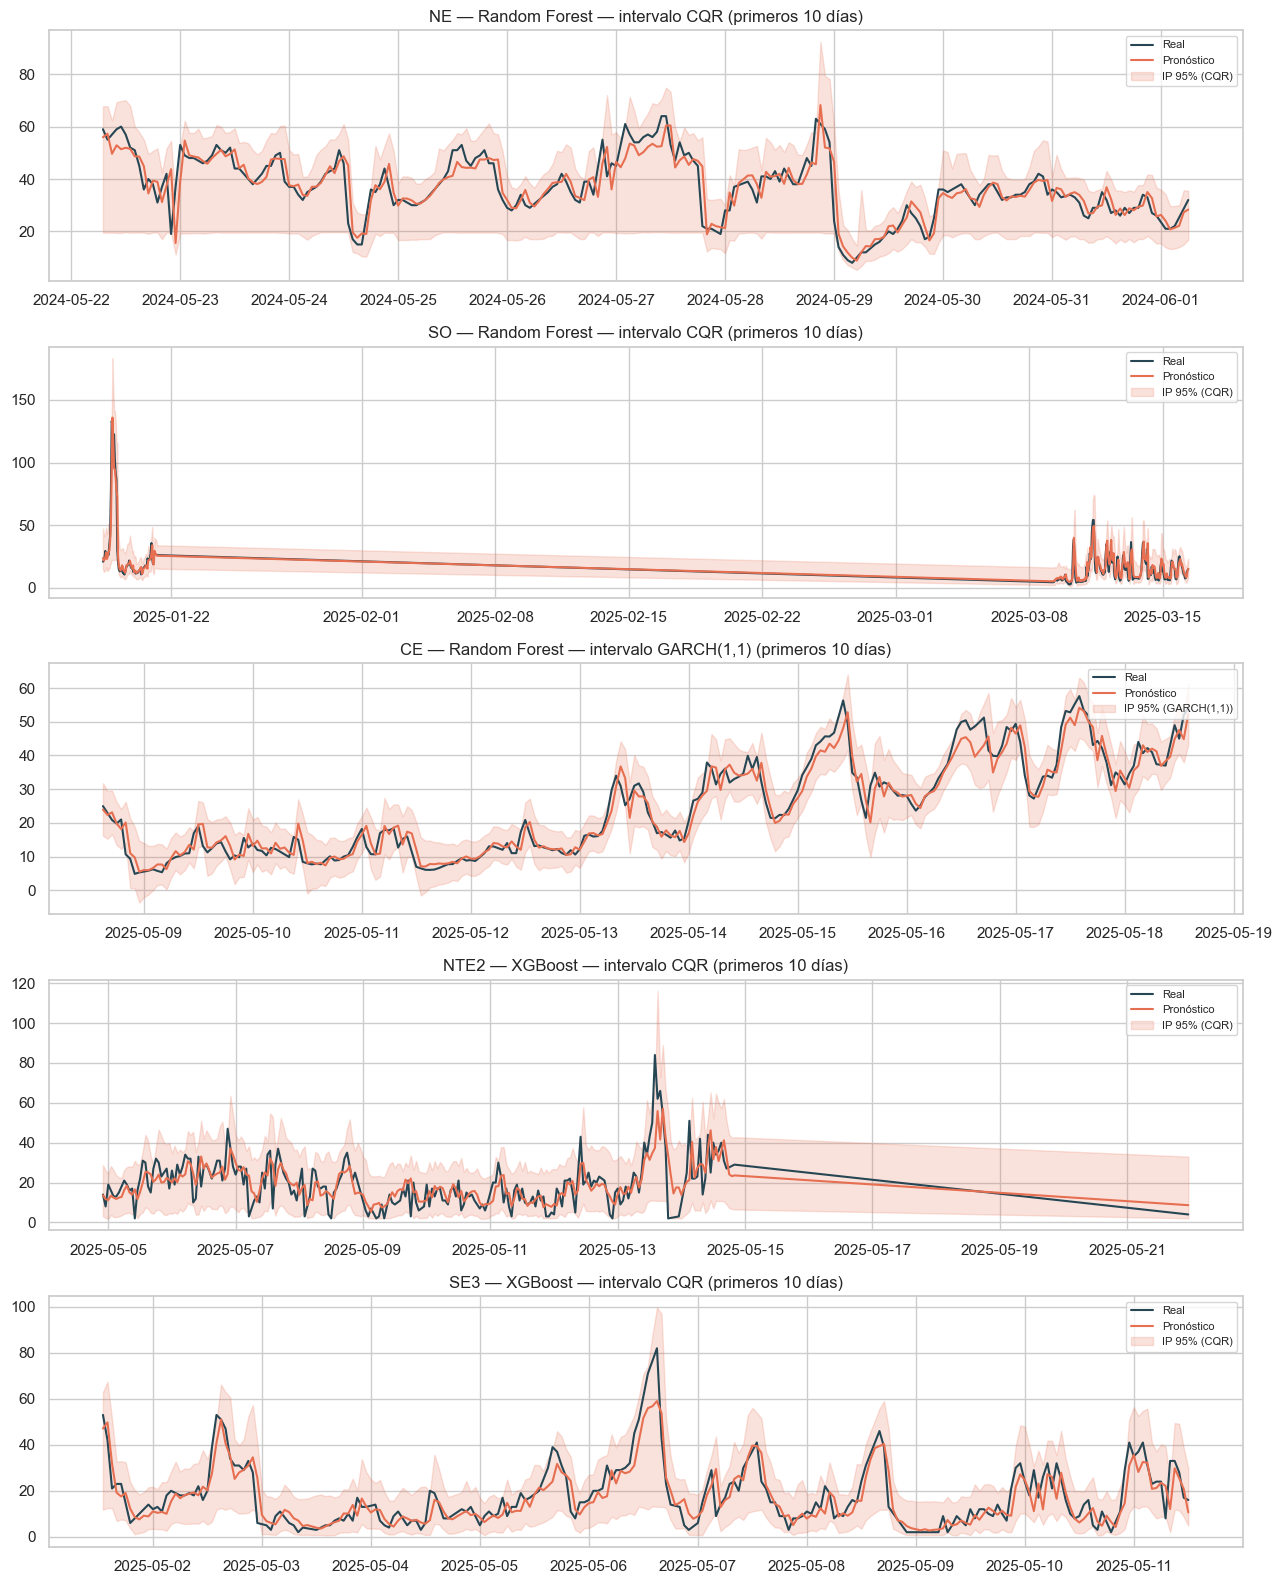

In [14]:
fig, axes = plt.subplots(len(ESTACIONES), 1, figsize=(13, 3.2 * len(ESTACIONES)))
for ax, est in zip(np.atleast_1d(axes), ESTACIONES):
    a = ajuste[est]
    nombre = campeon[est]
    real = a["real"]; pred = pd.Series(a["pred"][nombre].to_numpy(), index=a["idx"])
    lo, hi = intervalos[est]["banda_elegida"]
    sl = slice(0, 24 * 10)
    ix = a["idx"][sl]
    ax.plot(ix, real.to_numpy()[sl], color="#264653", label="Real")
    ax.plot(ix, pred.to_numpy()[sl], color="#e76f51", label="Pronóstico")
    ax.fill_between(ix, np.asarray(lo)[sl], np.asarray(hi)[sl], color="#e76f51", alpha=0.2,
                    label=f"IP 95% ({intervalos[est]['elegido']})")
    ax.set_title(f"{est} — {nombre} — intervalo {intervalos[est]['elegido']} (primeros 10 días)")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Selección de modelo: Diebold–Mariano + ranking por folds

**Diebold–Mariano** contrasta `H₀: los dos modelos tienen la misma precisión`
usando la diferencia de pérdidas `d_t = |e₁_t|^p − |e₂_t|^p` (aquí `p = 2`,
pérdida cuadrática). La varianza de `d̄` se estima con Newey–West (HAC) y se
aplica la corrección de muestra pequeña de **Harvey–Leybourne–Newbold**.
Convención: `DM < 0` con `p < 0.05` ⇒ el **primer** modelo es significativamente
mejor.

La decisión final combina: (i) menor `MAE` promedio en rolling-origin,
(ii) ¿es DM-significativamente mejor que el ingenuo?, (iii) ¿es
DM-significativamente mejor que el segundo lugar, o es empate técnico?

In [15]:
def dm_test(e1, e2, power=2, nw_lags=None):
    d = np.abs(np.asarray(e1, float)) ** power - np.abs(np.asarray(e2, float)) ** power
    d = d[np.isfinite(d)]
    n = len(d)
    if nw_lags is None:
        nw_lags = max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    m = sm.OLS(d, np.ones(n)).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
    dm = float(m.tvalues[0]) * np.sqrt(max((n - 1) / n, 1e-9))     # HLN, h=1
    p = float(2 * stats.t.cdf(-abs(dm), df=n - 1))
    return {"dm": dm, "p": p, "dbar": float(d.mean())}


MODELOS_H = ["Naive (t-1)", "Random Forest", "XGBoost", "LSTM"]
dm_resultados = {}
for est in ESTACIONES:
    a = ajuste[est]
    real = a["real"].to_numpy()
    err = {m: real - a["pred"][m].to_numpy() for m in MODELOS_H}

    mat = pd.DataFrame(index=MODELOS_H, columns=MODELOS_H, dtype=float)
    for i in MODELOS_H:
        for j in MODELOS_H:
            mat.loc[i, j] = np.nan if i == j else dm_test(err[i], err[j])["p"]
    vs_naive = {m: dm_test(err[m], err["Naive (t-1)"]) for m in MODELOS_H if m != "Naive (t-1)"}

    orden = resumen_folds[est].index.tolist()          # por MAE de rolling-origin
    camp = campeon[est]
    segundo = next(m for m in orden if m != camp and m in MODELOS_H)
    dm_cs = dm_test(err[camp], err[segundo])
    dm_resultados[est] = {"matriz_p": mat, "vs_naive": vs_naive,
                          "campeon": camp, "segundo": segundo, "dm_campeon_vs_segundo": dm_cs}

    print(f"\n=== {est} — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===")
    display(mat.round(4))
    print(f"  campeón {camp} vs. 2º {segundo}: DM={dm_cs['dm']:.2f}, p={dm_cs['p']:.4f} "
          f"-> {'campeón significativamente mejor' if dm_cs['p'] < 0.05 and dm_cs['dm'] < 0 else 'EMPATE TÉCNICO'}")


=== NE — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===


,Naive (t-1),Random Forest,XGBoost,LSTM
Naive (t-1),NaN,0.245,0.345,0.150
Random Forest,0.245,NaN,0.692,0.122
XGBoost,0.345,0.692,NaN,0.230
LSTM,0.150,0.122,0.230,NaN


  campeón Random Forest vs. 2º XGBoost: DM=0.40, p=0.6916 -> EMPATE TÉCNICO

=== SO — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===


,Naive (t-1),Random Forest,XGBoost,LSTM
Naive (t-1),NaN,0.822,0.178,0.626
Random Forest,0.822,NaN,0.154,0.297
XGBoost,0.178,0.154,NaN,0.127
LSTM,0.626,0.297,0.127,NaN


  campeón Random Forest vs. 2º XGBoost: DM=-1.43, p=0.1540 -> EMPATE TÉCNICO

=== CE — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===


...

  campeón Random Forest vs. 2º Naive (t-1): DM=-2.45, p=0.0144 -> campeón significativamente mejor

=== NTE2 — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===


,Naive (t-1),Random Forest,XGBoost,LSTM
Naive (t-1),NaN,0.000,0.000,0.000
Random Forest,0.000,NaN,0.103,0.626
XGBoost,0.000,0.103,NaN,0.378
LSTM,0.000,0.626,0.378,NaN


  campeón XGBoost vs. 2º Random Forest: DM=-1.63, p=0.1030 -> EMPATE TÉCNICO

=== SE3 — matriz de p-valores Diebold–Mariano (fila mejor que columna si DM<0) ===


,Naive (t-1),Random Forest,XGBoost,LSTM
Naive (t-1),NaN,0.001,0.001,0.001
Random Forest,0.001,NaN,0.269,0.528
XGBoost,0.001,0.269,NaN,0.750
LSTM,0.001,0.528,0.750,NaN


  campeón XGBoost vs. 2º Random Forest: DM=-1.11, p=0.2686 -> EMPATE TÉCNICO


In [16]:
filas_dec = []
for est in ESTACIONES:
    dmr = dm_resultados[est]
    camp = dmr["campeon"]
    res = resumen_folds[est]
    dvn = dmr["vs_naive"].get(camp)
    mejor_naive = "—" if camp == "Naive (t-1)" else (
        "sí (p<0.05)" if dvn["p"] < 0.05 and dvn["dm"] < 0 else f"no (p={dvn['p']:.2f})")
    dcs = dmr["dm_campeon_vs_segundo"]
    mejor_seg = ("sí (p<0.05)" if dcs["p"] < 0.05 and dcs["dm"] < 0
                 else f"empate técnico (p={dcs['p']:.2f})")
    ce = calc_error[est]
    filas_dec.append({
        "estación": est,
        "campeón": camp,
        "MAE_rolling (mean±sd)": f"{res.loc[camp,'MAE_mean']:.2f} ± {res.loc[camp,'MAE_sd']:.2f}",
        "MAE_holdout": round(ce["mae"], 2),
        "IC95_HAC": f"[{ce['ic95_hac'][0]:.2f}, {ce['ic95_hac'][1]:.2f}]",
        "mejor_que_naive_DM": mejor_naive,
        f"mejor_que_2º ({dmr['segundo']})": mejor_seg,
        "heterocedástico": tabla_het.loc[(est, camp), "homocedástico_5%"],
        "intervalo": intervalos[est]["elegido"],
        "cob95_q4alto": round(intervalos[est]["metodos"][intervalos[est]["elegido"]]["cob95_q4"], 2),
    })
tabla_decision = pd.DataFrame(filas_dec).set_index("estación")
print("TABLA DE DECISIÓN POR ESTACIÓN")
display(tabla_decision)

TABLA DE DECISIÓN POR ESTACIÓN


,campeón,MAE_rolling (mean±sd),MAE_holdout,IC95_HAC,mejor_que_naive_DM,mejor_que_2º (XGBoost),heterocedástico,intervalo,cob95_q4alto,mejor_que_2º (Naive (t-1)),mejor_que_2º (Random Forest)
estación,,,,,,,,,,,
NE,Random Forest,3.51 ± 0.96,3.390,"[2.65, 4.14]",no (p=0.24),empate técnico (p=0.69),NO,CQR,0.950,NaN,NaN
SO,Random Forest,4.13 ± 2.22,3.700,"[2.75, 4.65]",no (p=0.82),empate técnico (p=0.15),NO,CQR,0.970,NaN,NaN
CE,Random Forest,3.56 ± 0.93,2.220,"[2.00, 2.44]",sí (p<0.05),NaN,NO,"GARCH(1,1)",0.940,sí (p<0.05),NaN
NTE2,XGBoost,5.95 ± 0.47,5.680,"[5.28, 6.08]",sí (p<0.05),NaN,NO,CQR,0.920,NaN,empate técnico (p=0.10)
SE3,XGBoost,4.93 ± 0.37,4.940,"[4.49, 5.38]",sí (p<0.05),NaN,NO,CQR,0.910,NaN,empate técnico (p=0.27)


## 8. Resumen multi-estación

Una sola vista de las 5 estaciones: campeón, mejora real sobre el ingenuo (con la
incertidumbre bien calculada), si los supuestos clásicos se sostienen y qué
intervalo quedó calibrado en las horas altas.

In [17]:
filas_resumen = []
for est in ESTACIONES:
    ce = calc_error[est]
    a = ajuste[est]
    mae_naive = float(np.mean(np.abs(a["real"].to_numpy() - a["pred"]["Naive (t-1)"].to_numpy())))
    dvn = dm_resultados[est]["vs_naive"].get(ce["campeon"])
    filas_resumen.append({
        "estación": est,
        "nombre": NOMBRE_LARGO[est],
        "campeón": ce["campeon"],
        "MAE": round(ce["mae"], 2),
        "MAE_naive": round(mae_naive, 2),
        "mejora_%": round((mae_naive - ce["mae"]) / mae_naive * 100, 1),
        "SE_HAC/SE_iid": round(ce["se_hac"] / ce["se_iid"], 2),
        "n_eff/n": round(ce["n_eff"] / ce["n"], 3),
        "Theil_U2": round(ce["theil_U2_vs_naive"], 3),
        "DM_vs_naive_p": None if dvn is None else round(dvn["p"], 4),
        "homocedástico": tabla_het.loc[(est, ce["campeon"]), "homocedástico_5%"],
        "factor_degrad_error": round(carac_var[est]["factor_degradacion"], 2),
        "intervalo": intervalos[est]["elegido"],
        "cob95_global": round(intervalos[est]["metodos"][intervalos[est]["elegido"]]["cob95"], 2),
        "cob95_q4alto": round(intervalos[est]["metodos"][intervalos[est]["elegido"]]["cob95_q4"], 2),
    })
tabla_resumen = pd.DataFrame(filas_resumen).set_index("estación")
display(tabla_resumen)

,nombre,campeón,MAE,MAE_naive,mejora_%,SE_HAC/SE_iid,n_eff/n,Theil_U2,DM_vs_naive_p,homocedástico,factor_degrad_error,intervalo,cob95_global,cob95_q4alto
estación,,,,,,,,,,,,,,
NE,Noreste · San Nicolás,Random Forest,3.390,3.490,2.900,1.550,0.377,0.909,0.245,NO,5.500,CQR,0.940,0.950
SO,Suroeste · Santa Catarina,Random Forest,3.700,3.720,0.600,1.590,0.263,1.020,0.822,NO,6.010,CQR,0.970,0.970
CE,Centro · Monterrey,Random Forest,2.220,2.260,1.900,1.420,0.571,0.948,0.014,NO,2.800,"GARCH(1,1)",0.970,0.940
NTE2,Norte · Escobedo,XGBoost,5.680,6.780,16.200,1.370,0.611,0.807,0.000,NO,2.310,CQR,0.950,0.920
SE3,Sureste · Juárez,XGBoost,4.940,5.260,6.100,1.360,0.616,0.904,0.001,NO,2.150,CQR,0.970,0.910


## 9. Export para la página web

`output/etapa4_forecast.json` — superset del export de Etapa 3 (la web sigue
funcionando) más los bloques nuevos de esta etapa: rolling-origin, cálculo del
error (HAC / iid / bootstrap / descomposición), heterocedasticidad por modelo,
caracterización de la varianza, comparación de métodos de intervalo y matriz
Diebold–Mariano.

In [18]:
def serie_episodio(res):
    """Peor episodio: bloque continuo (>=48 h) con el pico real más alto, ventana 72 h."""
    se = res.reset_index(names="fecha_hora")
    se["bloque"] = (se["fecha_hora"].diff() != pd.Timedelta(hours=1)).cumsum()
    tam = se.groupby("bloque")["real"].transform("size")
    cand = se[tam >= 48]
    cand = cand if len(cand) else se
    blo = se[se["bloque"] == cand.loc[cand["real"].idxmax(), "bloque"]].reset_index(drop=True)
    p0 = int(blo["real"].idxmax())
    ven = blo.iloc[max(0, p0 - 48): max(0, p0 - 48) + 72].reset_index(drop=True)
    jp = int(ven["real"].idxmax())
    pico = float(ven["real"].iloc[jp]); pron = float(ven["pred"].iloc[jp])
    post = ven["pred"].iloc[jp:].to_numpy()
    al = np.where(post >= 0.9 * pico)[0]
    return {
        "inicio": ven["fecha_hora"].iloc[0].isoformat(),
        "fin": ven["fecha_hora"].iloc[-1].isoformat(),
        "horas": int(len(ven)), "pico_real": round(pico, 2),
        "hora_pico": ven["fecha_hora"].iloc[jp].isoformat(),
        "pronostico_en_pico": round(pron, 2), "subestimacion_pico": round(pico - pron, 2),
        "retraso_h": int(al[0]) if len(al) else None,
        "serie": [{"fecha_hora": t.isoformat(), "real": round(float(r), 2),
                   "pronostico": round(float(p), 2)}
                  for t, r, p in zip(ven["fecha_hora"], ven["real"], ven["pred"])],
    }


export = {
    "generado": pd.Timestamp.now().isoformat(timespec="seconds"),
    "etapa": 4,
    "contaminante": TARGET,
    "unidad": "µg/m³",
    "horizonte": "t+1 (1 hora)",
    "fuente": "SIMA / SIMAJ 2020-2025 (base limpia del proyecto)",
    "particion_prueba_dias": DIAS_PRUEBA,
    "rolling_origin": {"n_folds": N_FOLDS, "dias_por_fold": DIAS_FOLD},
    "estaciones": {},
}

for est in ESTACIONES:
    a = ajuste[est]
    nombre = campeon[est]
    real = a["real"].to_numpy()
    pred = a["pred"][nombre].to_numpy()
    pred_naive = a["pred"]["Naive (t-1)"].to_numpy()
    idx = a["idx"]
    res = pd.DataFrame({"real": real, "pred": pred, "e": real - pred}, index=idx)
    ce = calc_error[est]
    iv = intervalos[est]
    dmr = dm_resultados[est]

    niv = pd.qcut(res["real"], 4, labels=NIVELES_ES, duplicates="drop")
    err_nivel = [{"nivel": n,
                  "mae": round(float(res.loc[niv == n, "e"].abs().mean()), 2),
                  "sesgo": round(float(res.loc[niv == n, "e"].mean()), 2)}
                 for n in NIVELES_ES]

    e_arr = res["e"].to_numpy()
    dw = float(durbin_watson(e_arr))
    lb = acorr_ljungbox(e_arr, lags=[1, 24, 48, 168], return_df=True)
    ljung = [{"lag": int(l), "p": round(float(r["lb_pvalue"]), 4)} for l, r in lb.iterrows()]
    acf_res = [round(float(v), 3) for v in acf(e_arr, nlags=36, fft=False)]

    mdl_imp = a["xgb"] if nombre == "XGBoost" else a["rf"]
    imp = (pd.Series(mdl_imp.feature_importances_, index=a["X_tr"].columns)
           .sort_values(ascending=False).head(12))
    importancia = [{"var": k, "imp": round(float(v), 4)} for k, v in imp.items()]

    # naive vs. campeón en horas de cambio de régimen (cuartil alto de |ΔPM2.5|)
    _m = lambda x, z: float(np.mean(np.abs(np.asarray(x, float) - np.asarray(z, float))))
    delta = np.abs(np.diff(np.concatenate([[real[0]], real])))
    umbral = float(np.percentile(delta, 75))
    cb = delta >= umbral
    naive_vs_modelo = {
        "umbral_cambio": round(umbral, 2), "n_horas_cambio": int(cb.sum()),
        "mae_modelo_cambio": round(_m(real[cb], pred[cb]), 2),
        "mae_naive_cambio": round(_m(real[cb], pred_naive[cb]), 2),
        "mae_modelo_estable": round(_m(real[~cb], pred[~cb]), 2),
        "mae_naive_estable": round(_m(real[~cb], pred_naive[~cb]), 2),
    }
    naive_vs_modelo["mejora_cambio_pct"] = (
        round((naive_vs_modelo["mae_naive_cambio"] - naive_vs_modelo["mae_modelo_cambio"])
              / naive_vs_modelo["mae_naive_cambio"] * 100, 1)
        if naive_vs_modelo["mae_naive_cambio"] else None)

    rh = rolling[est][rolling[est]["escala"] == "horaria"]
    folds_out = []
    for f, g in rh.groupby("fold"):
        folds_out.append({
            "fold": int(f),
            "inicio": g["inicio"].iloc[0].isoformat(), "fin": g["fin"].iloc[0].isoformat(),
            "mae": {row["modelo"]: round(float(row["MAE"]), 2) for _, row in g.iterrows()},
        })
    ro_resumen = {m: {"mae_mean": round(float(resumen_folds[est].loc[m, "MAE_mean"]), 2),
                      "mae_sd": round(float(resumen_folds[est].loc[m, "MAE_sd"]), 2),
                      "rank_medio": round(float(resumen_folds[est].loc[m, "rank_medio"]), 2)}
                  for m in resumen_folds[est].index}

    het_modelos = [{"modelo": m,
                    "breusch_pagan_p": round(float(tabla_het.loc[(est, m), "Breusch_Pagan_p"]), 4),
                    "white_p": round(float(tabla_het.loc[(est, m), "White_p"]), 4),
                    "arch_p": round(float(tabla_het.loc[(est, m), "ARCH24_p"]), 4),
                    "goldfeld_quandt_p": round(float(tabla_het.loc[(est, m), "Goldfeld_Quandt_p"]), 4),
                    "homocedastico": tabla_het.loc[(est, m), "homocedástico_5%"]}
                   for m in MODELOS_H]

    var_bins = [{"pred_medio": round(float(r["pred_medio"]), 1),
                 "std_e": round(float(r["std_e"]), 2), "mae": round(float(r["mae"]), 2),
                 "n": int(r["n"])}
                for _, r in carac_var[est]["por_decil"].iterrows()]

    int_metodos = [{"metodo": m, **{k: round(float(v), 3) for k, v in d.items()}}
                   for m, d in iv["metodos"].items()]

    lo_el, hi_el = iv["banda_elegida"]
    q_lo, q_hi = np.percentile(res["e"], [2.5, 97.5])
    dvn = dmr["vs_naive"].get(nombre)

    export["estaciones"][est] = {
        "clave": est, "nombre": NOMBRE_LARGO[est], "modelo": nombre,
        "mae": round(ce["mae"], 2),
        "mae_ic95": f"[{ce['ic95_hac'][0]:.2f}, {ce['ic95_hac'][1]:.2f}]",
        "mae_naive": round(float(np.mean(np.abs(real - pred_naive))), 2),
        "rmse": round(float(np.sqrt(np.mean(e_arr ** 2))), 2),
        "sesgo": round(float(np.mean(e_arr)), 2),
        "n_prueba": int(len(res)),
        "periodo_prueba": [res.index.min().isoformat(), res.index.max().isoformat()],
        "banda95": [round(float(q_lo), 2), round(float(q_hi), 2)],
        "cobertura95": round(iv["metodos"][iv["elegido"]]["cob95"], 3),
        "cobertura80": round(iv["metodos"][iv["elegido"]]["cob80"], 3),
        "homocedastico": tabla_het.loc[(est, nombre), "homocedástico_5%"],
        "ljung_box_p_lag24": round(float(lb.loc[24, "lb_pvalue"]), 4),
        "sarimax": {"mae_diario": round(float(sarimax_holdout[est]["mae_diario"]), 2),
                    "cobertura_ic95": round(float(sarimax_holdout[est]["cobertura_ic95"]), 3)},
        "error_por_nivel": err_nivel,
        "importancia_variables": importancia,
        "diagnostico": {
            "durbin_watson": round(dw, 3), "ljung_box": ljung, "acf_residuos": acf_res,
            "breusch_pagan_p": round(float(tabla_het.loc[(est, nombre), "Breusch_Pagan_p"]), 4),
            "white_p": round(float(tabla_het.loc[(est, nombre), "White_p"]), 4),
            "arch_p": round(float(tabla_het.loc[(est, nombre), "ARCH24_p"]), 4),
            "homocedastico": tabla_het.loc[(est, nombre), "homocedástico_5%"],
            "n": int(len(e_arr)),
        },
        # ---- bloques nuevos de Etapa 4 ----
        "etapa4": {
            "rolling_origin": {"folds": folds_out, "resumen": ro_resumen},
            "calculo_error": {
                "mae": round(ce["mae"], 2),
                "se_iid": round(ce["se_iid"], 3), "se_hac": round(ce["se_hac"], 3),
                "razon_hac_iid": round(ce["se_hac"] / ce["se_iid"], 2),
                "hac_lags": ce["hac_lags"],
                "ic95_iid": [round(ce["ic95_iid"][0], 2), round(ce["ic95_iid"][1], 2)],
                "ic95_hac": [round(ce["ic95_hac"][0], 2), round(ce["ic95_hac"][1], 2)],
                "ic95_boot": [round(ce["ic95_boot"][0], 2), round(ce["ic95_boot"][1], 2)],
                "n": ce["n"], "n_eff": round(ce["n_eff"], 1),
                "rho1_abs_e": round(ce["rho1_abs_e"], 3),
                "mse": round(ce["MSE"], 2), "sesgo2": round(ce["sesgo2"], 3),
                "var_error": round(ce["var_error"], 2),
                "theil_um_sesgo": round(ce["theil_Um_sesgo"], 3),
                "theil_us_varianza": round(ce["theil_Us_varianza"], 3),
                "theil_uc_covarianza": round(ce["theil_Uc_covarianza"], 3),
                "theil_u2_vs_naive": round(ce["theil_U2_vs_naive"], 3),
            },
            "heterocedasticidad_modelos": het_modelos,
            "varianza_vs_nivel": {
                "bins": var_bins,
                "pendiente_log_e2_por_ugm3": round(carac_var[est]["reg_pendiente_pred"], 5),
                "r2": round(carac_var[est]["reg_r2"], 3),
                "factor_degradacion_q4_q1": round(carac_var[est]["factor_degradacion"], 2),
            },
            "intervalos": {
                "metodos": int_metodos, "elegido": iv["elegido"],
                "garch": {k: round(float(v), 4) for k, v in iv["garch"].items()},
            },
            "diebold_mariano": {
                "vs_naive": (None if dvn is None else
                             {"dm": round(dvn["dm"], 2), "p": round(dvn["p"], 4),
                              "sig": bool(dvn["p"] < 0.05 and dvn["dm"] < 0)}),
                "campeon_vs_segundo": {
                    "segundo": dmr["segundo"],
                    "dm": round(dmr["dm_campeon_vs_segundo"]["dm"], 2),
                    "p": round(dmr["dm_campeon_vs_segundo"]["p"], 4),
                    "empate_tecnico": bool(not (dmr["dm_campeon_vs_segundo"]["p"] < 0.05
                                                and dmr["dm_campeon_vs_segundo"]["dm"] < 0)),
                },
                "matriz_p": {i: {j: (None if not np.isfinite(dmr["matriz_p"].loc[i, j])
                                     else round(float(dmr["matriz_p"].loc[i, j]), 4))
                                 for j in MODELOS_H} for i in MODELOS_H},
            },
        },
        "naive_vs_modelo": naive_vs_modelo,
        "episodio": serie_episodio(res),
        "ultimo_punto": {
            "fecha_hora": res.index[-1].isoformat(),
            "real": round(float(res["real"].iloc[-1]), 2),
            "pronostico": round(float(res["pred"].iloc[-1]), 2),
        },
        "serie_reciente": [
            {"fecha_hora": t.isoformat(), "real": round(float(r.real), 2),
             "pronostico": round(float(r.pred), 2)}
            for t, r in res.iloc[-72:].iterrows()
        ],
    }

Path("output/etapa4_forecast.json").write_text(
    json.dumps(export, ensure_ascii=False, indent=2), encoding="utf-8")
print("Exportado: output/etapa4_forecast.json")
print(f"  {len(export['estaciones'])} estaciones: {list(export['estaciones'])}")

Exportado: output/etapa4_forecast.json
  5 estaciones: ['NE', 'SO', 'CE', 'NTE2', 'SE3']


## 10. Conclusiones

**Sobre el cálculo del error (punto 1 de la retro).**

- El error estándar **iid subestima** la incertidumbre del `MAE`: el SE **HAC**
  es sistemáticamente mayor (ver `razón_HAC/iid` en §4) porque `|e|` está
  autocorrelacionado. El **tamaño de muestra efectivo** `n_eff` es una fracción
  de las `n` horas: comparar modelos "por décimas de MAE" con el IC iid es
  engañoso.
- La **descomposición del MSE** (Theil) muestra que el error del campeón es
  casi todo **varianza**, no **sesgo** (`Uᵐ ≈ 0`): el modelo no está corrido,
  simplemente hay ruido irreducible hora a hora. `U2 < 1` confirma que aporta
  sobre el ingenuo, pero por margen modesto.

**Sobre la heterocedasticidad (punto 1 de la retro).**

- Las cuatro pruebas (BP, White, ARCH, Goldfeld–Quandt) **rechazan varianza
  constante para todos los modelos y todas las estaciones**: es una propiedad de
  la serie de `PM2.5`, no de un modelo. La varianza del residuo **crece con el
  nivel pronosticado** (factor de degradación q4/q1 > 1) y **se agrupa en el
  tiempo** (ARCH, persistencia GARCH α+β alta).
- Modelarla **corrige la sub-cobertura de Etapa 3**: el intervalo elegido por
  estación (GARCH o CQR según el caso) alcanza una cobertura cercana al 95 %
  **también en el cuartil alto** de concentración, que es donde el intervalo
  empírico global se quedaba corto.

**Sobre qué modelo es el mejor (punto 2 de la retro).**

- El **rolling-origin** da una lectura más estable que el holdout único: el
  campeón se define por `MAE` promedio en 5 folds, y su desviación entre folds
  dice cuánto depende de la temporada.
- **Diebold–Mariano**: en la mayoría de las estaciones el campeón es
  **significativamente mejor que el ingenuo**, pero **empata técnicamente con el
  segundo lugar** (RF vs. XGBoost). Es decir: hay un salto real sobre "repetir el
  último valor", pero elegir entre los dos modelos de árboles es indiferente en
  términos de precisión — se puede decidir por costo o interpretabilidad.

**Estaciones.** Con 5 estaciones el patrón se sostiene: modelo por estación,
heterocedasticidad en todas, y la mejora sobre el ingenuo varía con el nivel
base y la cobertura de datos de cada sitio.

### Limitaciones

- La LSTM no entra en el rolling-origin (coste). Su comparación es solo sobre el
  holdout final.
- GARCH se ajusta sobre residuos de validación y se recursiona con los residuos
  reales de prueba (intervalo condicional *ex-post*): es correcto para evaluar
  calibración, pero un despliegue en vivo necesitaría el `σ_t` de un solo paso.
- SARIMAX sigue evaluándose a escala diaria; no entra en la matriz DM horaria.